In [57]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTaskNP as FeatureSiftingTask

In [ ]:
SEED = 0
INPUT_DIM = 20

In [11]:
task = FeatureSiftingTask(n_learner_features=INPUT_DIM, seed=SEED)

In [54]:
from enum import Enum

class FeatureStatus(Enum):
    TENURED = 'tenured'
    PENDING = 'pending'

# V1: LMS

In [ ]:
### Task init ###
task = FeatureSiftingTask(n_learner_features=INPUT_DIM, seed=SEED)
x, y = task.step(np.zeros(INPUT_DIM))

### Parameters ###
step_size = 0.01
train_steps = 5000
log_freq = 500

### Network init ###
weight_init_bound = np.sqrt(3/INPUT_DIM)
weights = np.random.uniform(-weight_init_bound, weight_init_bound, size=INPUT_DIM)

losses = []

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    losses.append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### New sample ###
    x, y = task.step(np.zeros(INPUT_DIM))
    
    ### Logging ###
    if (i + 1) % log_freq == 0:
        print(f'Step {i + 1} loss: {np.mean(losses[-log_freq:])}')


Step 500 loss: 2.2430513118028674
Step 1000 loss: 1.3085407885929043
Step 1500 loss: 1.1232128234687662
Step 2000 loss: 1.1908739173836957
Step 2500 loss: 1.2034042857338114
Step 3000 loss: 1.1481068260031708
Step 3500 loss: 1.271634766598071
Step 4000 loss: 1.229372328851358
Step 4500 loss: 1.2642576450435095
Step 5000 loss: 1.152358563725406


# V2: Utility-Based Pruning


Step 500 loss: 2.1665148648981005
Step 1000 loss: 0.8874197044980565
Step 1500 loss: 0.6428190245004156
Step 2000 loss: 0.7402409864884371
Step 2500 loss: 0.43276386845806397
Step 3000 loss: 0.4066292404868483
Step 3500 loss: 0.4249509494524427
Step 4000 loss: 0.33326343845942136
Step 4500 loss: 0.33441602650380564
Step 5000 loss: 0.3055290017657443


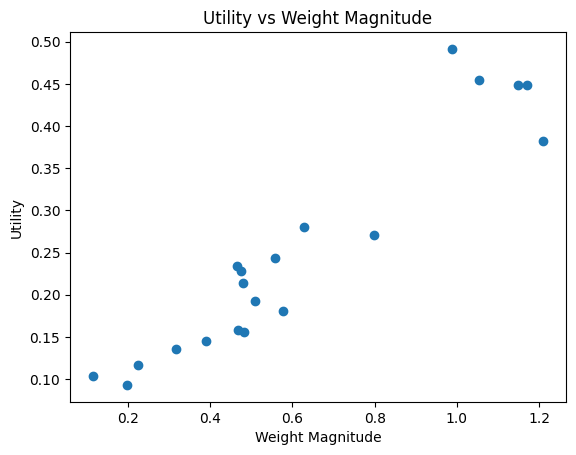

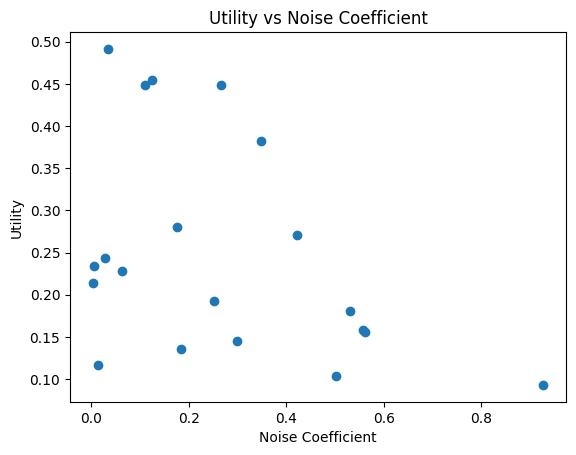

In [70]:
### Task init ###
task = FeatureSiftingTask(n_learner_features=INPUT_DIM, seed=SEED)
x, y = task.step(np.zeros(INPUT_DIM))

### Parameters ###
step_size = 0.01
train_steps = 5000
log_freq = 500
ema_decay = 0.98
prune_freq = int(2 / (1 - ema_decay))

### Network init ###
weight_init_bound = np.sqrt(3/INPUT_DIM)
weights = np.random.uniform(-weight_init_bound, weight_init_bound, size=INPUT_DIM)
utilities = np.zeros(INPUT_DIM)

losses = []

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    losses.append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### Utility update ###
    step_utilities = np.abs(x * weights)
    utilities = ema_decay * utilities + (1 - ema_decay) * step_utilities
    
    ### Pruning ###
    prune_mask = np.zeros(INPUT_DIM)
    if (i + 1) % prune_freq == 0:
        lowest_idx = np.argmin(utilities)
        utilities[lowest_idx] = np.median(utilities)
        weights[lowest_idx] = np.random.uniform(-weight_init_bound, weight_init_bound)
        prune_mask[lowest_idx] = 1
    
    ### New sample ###
    x, y = task.step(prune_mask)
    
    ### Logging ###
    if (i + 1) % log_freq == 0:
        print(f'Step {i + 1} loss: {np.mean(losses[-log_freq:])}')

plt.scatter(np.abs(weights), utilities)
plt.xlabel('Weight Magnitude')
plt.ylabel('Utility')
plt.title('Utility vs Weight Magnitude')
plt.show()

plt.scatter(task.noise_coefficients, utilities)
plt.xlabel('Noise Coefficient')
plt.ylabel('Utility')
plt.title('Utility vs Noise Coefficient')
plt.show()



In [14]:
y

-1.633026867852524

In [15]:
task.noise_coefficients

array([0.81585355, 0.0027385 , 0.85740428, 0.03358558, 0.72965545,
       0.17565562, 0.86317892, 0.54146122, 0.29971189, 0.42268722,
       0.02831967, 0.12428328, 0.67062441, 0.64718951, 0.61538511,
       0.38367755, 0.99720994, 0.98083534, 0.68554198, 0.65045928])